# Lab 9: Contagion Models

**How you will be graded**

This activity is out of 10 points. You will be graded on three things: completion, clear documentation, and correctness of your process.

* *Completion (4pts)*: This is solely whether you attempted and completed all portions of the computational assignment.
* *Documentation (4pts)*: Write comments above your code, describing what it does to demonstrate that you understand what the code is doing.
* *Correctness (2pts)*: Does your code run and produce the correct output?


# Playground!

In this section you will be given a set of tasks to complete on your own, and you will have to figure out how to do them using the resources provided (videos, documentation, etc). This way you can learn at your own pace and also get used to looking up documentation and learning how to use new tools on your own.

The very first task is to import the required packages, in this lab we will code up models of disease spread. To do that we will use `numpy`, `matplotlib.pyplot`, and `networkx`

Try importing the required libraries below (dont forget you can use the `as` keyword to give them a shorter alias):

In [1]:
import networkx as nx
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# 1. Compartmental SI model

The most basic model of disease spread assumes a well mixed population with only two clases,
-   **$S(t)$** : The suscpetible class indicating the number (or proportion) of susceptible individuals in the population at time $t$.
-   **$I(t)$** : The infected class indicating the number (or proportion) of infected individuals in the population at time $t$.

These are the key variables which end up changing as more and more individuals become infected or as the infected individuals recover!

To model the spread of disease we assume that as the susceptible class come into contact with the infected class they have a chance of contracting the disease, we say that the parameter $\beta$ captures the probability of becoming infected after a contact. The probability (or frequency) of susceptible-infected contacts can be given by - $S(t)*I(t)$

This means at each time step $\beta S(t)I(t)$ susceptible individuals become infected, so the change in each population can be written as,
-   $\dfrac{dS}{dt} = -\beta S(t)I(t)$
-   $\dfrac{dI}{dt} = \beta S(t)I(t)$

So we are now using derivates, they might seem scary but they are quite simple to understand. They tell us one simple thing, **How fast is something changing?**. With respect to the SI model, they tell us **How quickly the number of susceptible/infected individuals is changing at this moment in time**.

### 1.1 Using the Euler's method
Now let's see how we can use computation to model these dynamics! Modeling derivates is not the easiest so we can sometimes use approximations, Euler's method gives us a great framework to model these derivates and its really easy to understand!

Euler's method uses the derivates to show how $S(t+\Delta t)$ depends on $S(t)$ (or $I(t+\Delta t)$ on $I(t)$),
-   $S(t+\Delta t) = S(t) + \Delta t \dfrac{dS}{dt}$
-   $I(t+\Delta t) = I(t) + \Delta t \dfrac{dI}{dt}$

The above equations migh seem complicated but they just say that $S(t+\Delta t)$ is equal to $S(t)$ plus change in $S$ in the time step $\Delta t$. We can put our values for the derivates from before and get the final equations we will use to create our models!
-   $S(t+\Delta t) = S(t) - \Delta t \beta S(t)I(t)$
-   $I(t+\Delta t) = I(t) + \Delta t \beta S(t)I(t)$  

We can now create our model!

Hint: $\Delta t$ might seem confusing, but it just the difference between two consecutive time steps in our model, if we sample our population at time 100 and 100.1 then $\Delta t = 0.1$ and we use it to scale our change.

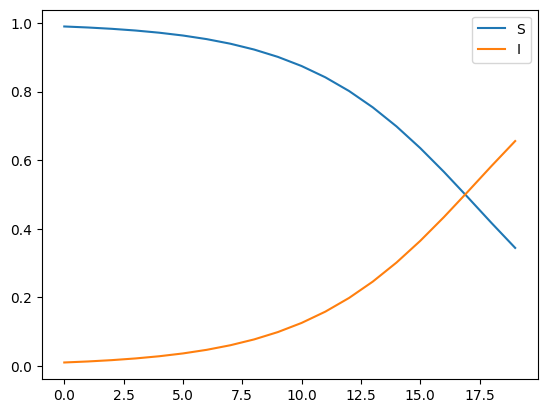

In [4]:
# Euler's method for SI models (For simplicity we assume delta t = 1)

# TODO: Fill in some values for our parameters
beta = 0.3 # This is the probability of catching a disease, its always <1
T = 20 # How long we run our simulation.

# TODO: Define some initial values for our variables
S = [0.99] # These are the lists where we store the frequencies for each class, initially we will only have a single value in these list which initialize our population.
I = [0.01] # Think of them as the percentage of total population in a class (S or I)

# TODO: Create a loop to run (T-1) times
for t in range(T - 1):
    # TODO: How will S change at each time step?
    S_change = -beta * S[t] * I[t]
    # Finding S(t+dt) from S(t)
    S_new = S[t] + S_change

    # TODO: How will I change at each time step?
    I_change = beta * S[t] * I[t]
    I_new = I[t] + I_change

    # Adding these new values to our lists
    S.append(S_new)
    I.append(I_new)

# Plot S and I wrt T (Hint: Use range(T))
plt.plot(range(T), S, label = "S")
plt.plot(range(T), I, label = "I")
plt.legend()
plt.show()

# 2. Integrating contact networks
The previous model has a huge assumption, the population is assumed to be well-mixed! This means each individual in a class has an equal chance of bumping into another class at a specific time point. Thats not always true, if someone is less social then they should have less contacts and hence a lower chance of becoming infected. 

So we can integrate the previous model with networks to more accurately show disease spread in a realistic population.

How does the previous model change?

First of all, since we are not assuming a well-mixed population, we will now need to track the state of each individual. So our $S(t)$ and $I(t)$ become arrays of size N (Where N is the total population). On top of that we also need our contact network, for this excercise we can use the Zachary karate club network, but one could experiment with different styles of networks (like ER and PA).

Most importantly our equations change to,
- $S(t+\Delta t) = S(t) - \Delta t \beta S(t) (A \cdot I(t))$
- $I(t+\Delta t) = I(t) + \Delta t \beta S(t) (A \cdot I(t))$

Where A is our adjacency matrix, how do you think A is modifying our equation? What does it achieve?

**Student answer here**

Note: Even though each element in our S and I arrays will be an indivual, the values of these elements will be between 0 and 1, does that mean half of our individual is susceptible and half infeted? Not really, its just a way of representation, it just tells us the probability that our individual is susceptible or infected.


Text(0, 0.5, 'Prob. of being infected')

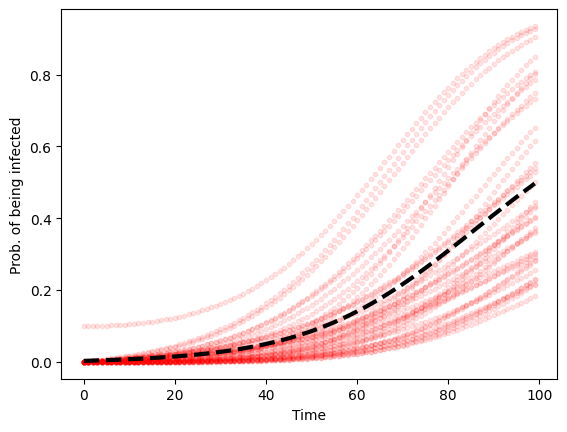

In [11]:
# Eulers method for networks

# Parameters
T = 100
G = nx.karate_club_graph()
A = nx.to_numpy_array(G)
# TODO: Define the rest (what else do we need based on the previous excercise)
beta = 0.003 # Probability of infection spread, same as before (<1)

# TODO: Define intial variables
S0 = np.ones(A.shape[0]) # What should be the size of our initial arrays?
S0[0] = 0.9 # Making one individual in our poplation a little bit infected
I0 = np.zeros(A.shape[0])
I0[0] = 0.1 # All values should add to 1

# TODO: Initialize lists to store these arrays
S = [S0]
I = [I0]

# TODO: Create the loop
for t in range(T - 1):
    # TODO: How will S change?
    S_change = -beta * S[t] * (A @ I[t]) # Each node can be infected by its neighbors
    S_new = S[t] + S_change

    # TODO: Same for I
    I_change = beta * S[t] * (A @ I[t])
    I_new = I[t] + I_change

    # TODO: Add them to you lists
    S.append(S_new)
    I.append(I_new)

# Plotting (Comment what you think is happening here)
for i in range(T):
    plt.scatter(i * np.ones(I[i].shape), I[i], color = 'red', s = 10, alpha = 0.1)

plt.plot(range(T), [j.mean() for j in I], 'k--', linewidth = 3)

plt.xlabel("Time")
plt.ylabel("Prob. of being infected")


# 3. Stochastic model

We can incorporate even more realism in this framework, in reality an individual is either infected or not. So we can build that into our framework, instead of representing the probability that a person is infected, we can use that value to randomly change a susceptible person to an infected person.

In this model our $S(t)$ and $I(t)$ arrays will only contain either 0 or 1. The equations will change as well, now $\beta S(t) (A \cdot I(t))$ gives us the probability that an individual will get infected based on their connections, there is always a chance that an individual just never becomes infected!

Lets try modeling this below!

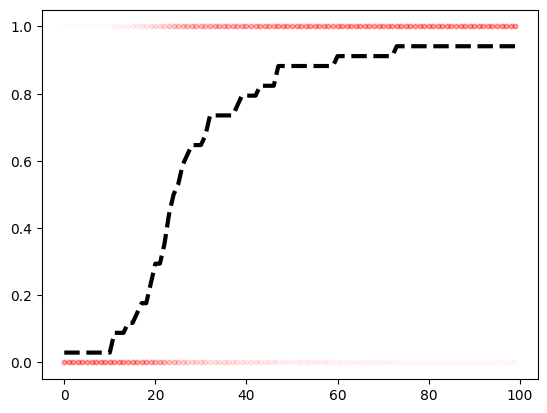

In [6]:
# Networks with markov

# Parameters
T = 100
G = nx.karate_club_graph()
A = nx.to_numpy_array(G)
beta = 0.01

# TODO: Define initial populations
S0 = np.ones(G.number_of_nodes())
S0[0] = 0.0 # Making one individual infected
I0 = np.zeros(G.number_of_nodes())
I0[0] = 1.0

# TODO: Store them
S = [S0]
I = [I0]

# TODO: Loop over time range
for t in range(T - 1):
    # TODO: Use the equations to create array of probabilities of becoming infected
    prob_array = 1 - np.exp(-beta * (A @ I[t]))  # Probability each node gets infected from neighbors

    # TODO: Initialize an array of zeros to store the new infected population
    I_new = np.zeros(G.number_of_nodes())
    # TODO: Loop over number of individuals
    for i in range(G.number_of_nodes()):
        # Whats happening here?
        # Each susceptible individual can become infected with prob_array[i];
        # infected ones remain infected.
        if I[t][i] == 0:
            I_new[i] = int(np.random.rand() < prob_array[i])
        else:
            I_new[i] = 1

    # Storing values
    S.append(1 - I_new) # S = 1 - I since we only have two compartments
    I.append(I_new)

# Plotting
for i in range(T):
    plt.scatter(i * np.ones(I[i].shape), I[i], color='red', s=10, alpha=0.01)

plt.plot(range(T), [j.mean() for j in I], 'k--', linewidth=3)


# Extra Credit (3 points - 1 point for each model)

Usually infections are not permanent, individuals recover overtime. Assume that individuals recover with rate $\gamma$. Recreate the three models (Well-mixed ODEs, network model, and the stochastic model) to reflect this recovery term. When an individual recovers they instantly become susceptible again.

Hint: For the well-mixed ODE model, this is what the equations would look like,
-   $\dfrac{dS}{dt} = -\beta S(t)I(t) + \gamma I(t)$
-   $\dfrac{dI}{dt} = \beta S(t)I(t) - \gamma I(t)$

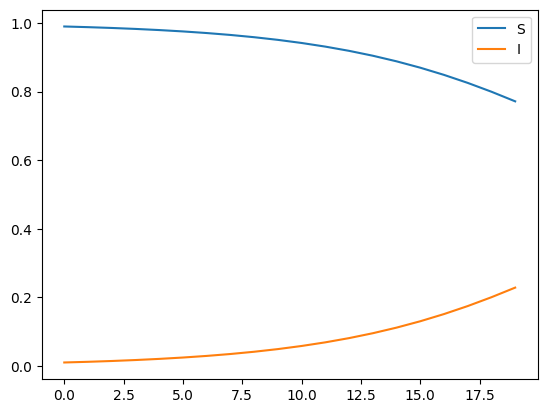

In [8]:
# Well-mixed ODE SIS model

beta = 0.3
gamma = 0.1
T = 20

S = [0.99]
I = [0.01]

for t in range(T - 1):
    S_change = -beta * S[t] * I[t] + gamma * I[t]
    I_change = beta * S[t] * I[t] - gamma * I[t]

    S_new = S[t] + S_change
    I_new = I[t] + I_change

    S.append(S_new)
    I.append(I_new)

plt.plot(range(T), S, label = "S")
plt.plot(range(T), I, label = "I")
plt.legend()
plt.show()


/var/folders/zx/62m5mk2j44z4ch67jbh6b0z80000gn/T/ipykernel_5433/1467910596.py:18: RuntimeWarning: overflow encountered in multiply
  S_change = -beta * S[t] * (A @ I[t]) + gamma * I[t]
/var/folders/zx/62m5mk2j44z4ch67jbh6b0z80000gn/T/ipykernel_5433/1467910596.py:19: RuntimeWarning: overflow encountered in multiply
  I_change = beta * S[t] * (A @ I[t]) - gamma * I[t]
/var/folders/zx/62m5mk2j44z4ch67jbh6b0z80000gn/T/ipykernel_5433/1467910596.py:18: RuntimeWarning: invalid value encountered in matmul
  S_change = -beta * S[t] * (A @ I[t]) + gamma * I[t]
/var/folders/zx/62m5mk2j44z4ch67jbh6b0z80000gn/T/ipykernel_5433/1467910596.py:19: RuntimeWarning: invalid value encountered in matmul
  I_change = beta * S[t] * (A @ I[t]) - gamma * I[t]


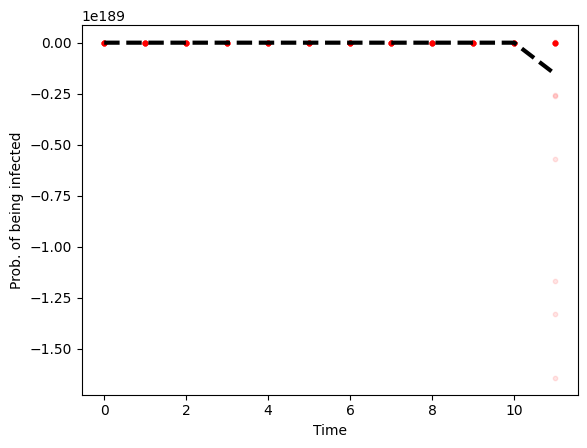

In [ ]:
# Euler

T = 100
G = nx.karate_club_graph()
A = nx.to_numpy_array(G)
beta = 0.3
gamma = 0.1 # implementing gamma

S0 = np.ones(A.shape[0])
S0[0] = 0.9
I0 = np.zeros(A.shape[0])
I0[0] = 0.1

S = [S0]
I = [I0]

for t in range(T - 1):
    S_change = -beta * S[t] * (A @ I[t]) + gamma * I[t]
    I_change = beta * S[t] * (A @ I[t]) - gamma * I[t]

    S_new = S[t] + S_change
    I_new = I[t] + I_change

    S.append(S_new)
    I.append(I_new)

for i in range(T):
    plt.scatter(i * np.ones(I[i].shape), I[i], color = 'red', s = 10, alpha = 0.1)
plt.plot(range(T), [j.mean() for j in I], 'k--', linewidth = 3)
plt.xlabel("Time")
plt.ylabel("Prob. of being infected")
plt.show()


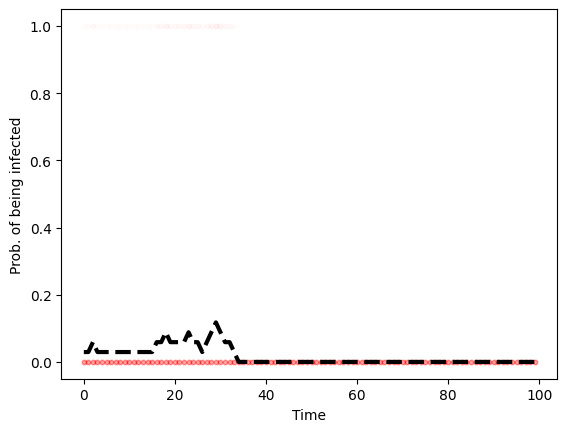

In [ ]:
# Networks w Markov

T = 100
G = nx.karate_club_graph()
A = nx.to_numpy_array(G)
beta = 0.01
gamma = 0.1 # implementing gamma

S0 = np.ones(G.number_of_nodes())
S0[0] = 0.0
I0 = np.zeros(G.number_of_nodes())
I0[0] = 1.0

S = [S0]
I = [I0]

for t in range(T - 1):
    # Infection probability and recovery probability
    prob_infect = 1 - np.exp(-beta * (A @ I[t]))
    prob_recover = gamma # individual recovery

    I_new = np.zeros(G.number_of_nodes())
    for i in range(G.number_of_nodes()):
        if I[t][i] == 0:
            # susceptible node becomes infected with probability prob_infect[i]
            I_new[i] = int(np.random.rand() < prob_infect[i])
        else:
            # infected node recovers with probability gamma, else stays infected
            I_new[i] = int(np.random.rand() >= prob_recover)

    S.append(1 - I_new)
    I.append(I_new)

for i in range(T):
    plt.scatter(i * np.ones(I[i].shape), I[i], color = 'red', s = 10, alpha = 0.01)
plt.plot(range(T), [j.mean() for j in I], 'k--', linewidth = 3)
plt.xlabel("Time")
plt.ylabel("Prob. of being infected")
plt.show()
